# ASTRO 501 — HW4b: Long-slit spectra of an extended object

<img src="pics/m57_color.jpg" width="500">

## Overview

In this homework, you will work with a real archival long-slit spectrum of the **Ring Nebula (M57)** taken with the KPNO 2.1 m CCD spectrometer (`ccd_spec`).

Your goals are to:

- locate a usable **science frame** and matching calibration files
- inspect the raw 2D spectrum and decide which features look astrophysical versus instrumental
- compare **nebular emission** to likely **sky-glow / airglow** features
- carry out a **rough wavelength calibration**
- extract spectra from different spatial regions along the slit and compare them
- identify several of the strongest nebular emission lines
- compare your line identifications to the visible colors in a color image of M57

You do **not** need a perfect professional reduction. A rough but well-explained result is completely acceptable.

## Files to download

Using the archive web interface from HW1b, go to:

`https://astroarchive.noirlab.edu/`

Search the **2011-07-25 local observing date** data from **`ccd_spec`** on the **KPNO 2.1 m** telescope and download these four files:

- one **300 s M57 object** exposure
- one **zero** frame
- one **flat** frame
- one **HeNeAr 20 s** comparison lamp frame

Use these specific files:

- `zero = 'k21i_110726_014903_zri.fits.fz'`
- `flat = 'k21i_110726_020027_fri.fits.fz'`
- `HeNeAr = 'k21i_110726_022022_cri.fits.fz'`
- `m57 = 'k21i_110726_104331_ori.fits.fz'`

The filenames use the **UT date** `110726`, which is why the downloaded filenames differ by one day from the local calendar date in the archive search.

Put all four files in the same directory as this notebook before running the code.


In [2]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['image.origin'] = 'lower'
plt.rcParams['axes.grid'] = False

DATA_DIR = Path('data/')
FILES = {
    'zero': DATA_DIR / 'k21i_110726_014903_zri.fits.fz',
    'flat': DATA_DIR / 'k21i_110726_020027_fri.fits.fz',
    'arc':  DATA_DIR / 'k21i_110726_022022_cri.fits.fz',
    'm57':  DATA_DIR / 'k21i_110726_104331_ori.fits.fz',
}
for key, path in FILES.items():
    print(f'{key:>4}: {path} exists={path.exists()}')


zero: data\k21i_110726_014903_zri.fits.fz exists=True
flat: data\k21i_110726_020027_fri.fits.fz exists=True
 arc: data\k21i_110726_022022_cri.fits.fz exists=True
 m57: data\k21i_110726_104331_ori.fits.fz exists=True


## P1. Data inspection [10 pts]

Before doing any analysis, inspect the raw files carefully.

### Tasks
- Load all four frames.
- Display the detector images using a stretch that makes both faint and bright structure visible.
- Briefly describe what you see in each image.

### Required output
- A 4-panel figure showing the four frames
- Short written comments on what each panel shows

### Things to look for
- the general orientation of the spectrum
- the slit direction versus the wavelength direction
- whether the science frame looks extended, point-like, or both
- whether the arc frame contains many narrow comparison lines
- whether the flat has strong large-scale structure
- obvious bad columns, bright stars, or cosmetic defects

<img src="pics/images4.jpg" width="1000">


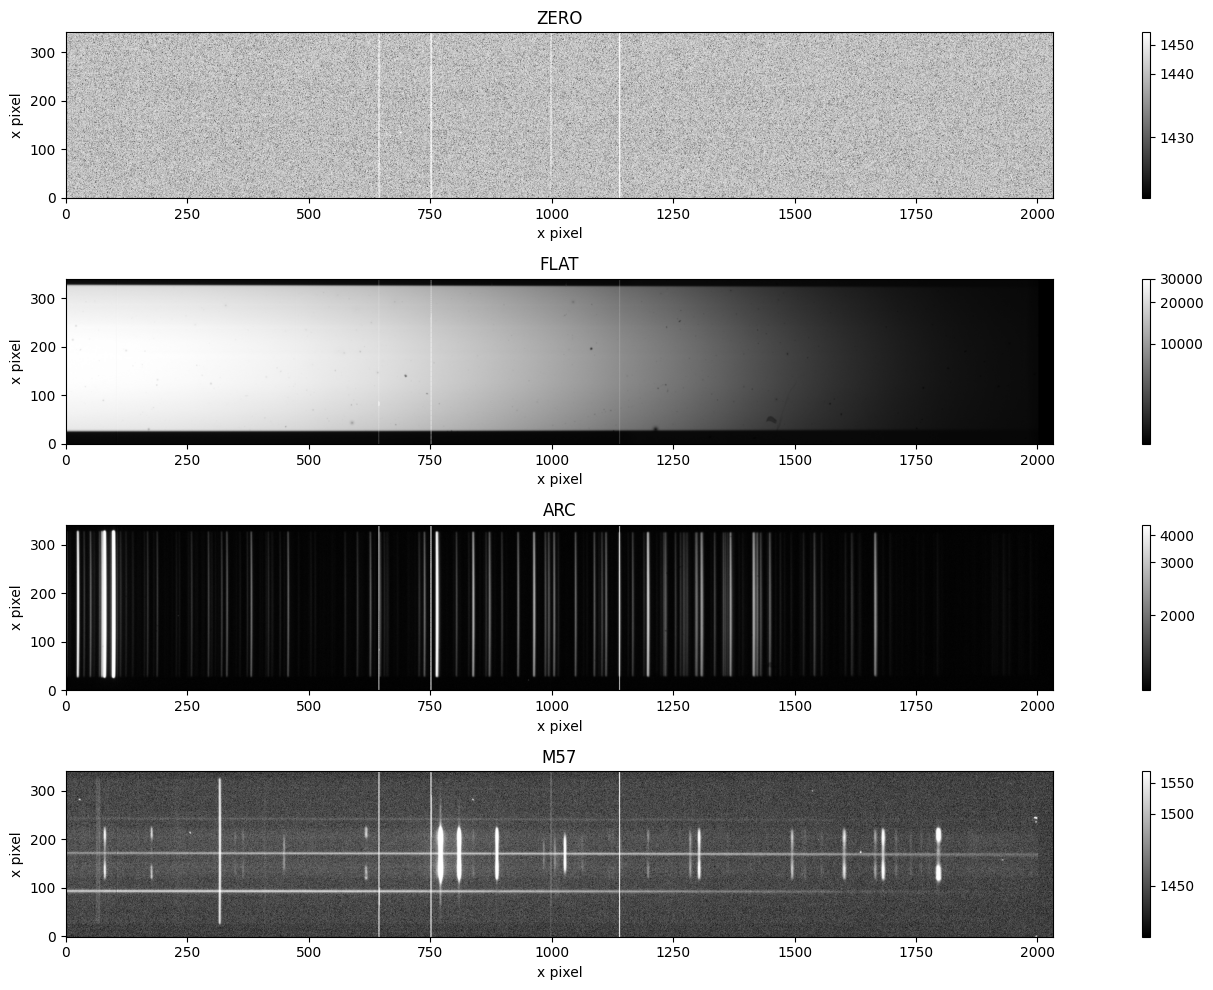

In [26]:
# P1
from astropy.visualization import simple_norm

fig, axes = plt.subplots(4,1, figsize=(18, 10))

images = {}

for ax, (key, path) in zip(axes, FILES.items()):
    with fits.open(path) as hdul:
        # Try primary HDU first, otherwise fallback to first extension
        data = hdul[0].data
        if data is None:
            data = hdul[1].data

    images[key] = data

    norm = simple_norm(data, stretch='asinh', percent=98.5)
    im = ax.imshow(data, norm=norm, cmap='gray')
    ax.set_title(key.upper())
    ax.set_xlabel("x pixel")
    ax.set_ylabel("x pixel")
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In the bias frame, we can see that most of the detector is simply noise, as expected, but there are a few vertical lines of higher values, which represent bad columns.

In the flat, we see the overall structure of the continuum-only spectrum across the detector that will be used to flat-field the science spectrum. We can still see the bad columns, and can also detect a few dark spots, representing possible dust in the optics. We can also see some slight vignetting, such that the vertical center of the detector is brighter than the upper and lower edges.

In the calibration lamp arc image, we can see that there are a lot of emission lines, corresponding to the spectrum of the elements in that lamp. Some are brighter than others, indicating stronger emission lines. There are also the same few bad columns.

Finally, in the M57 science frame, we can see the trace of the central star in the center, some emission lines that are only in the central region of the nebula, some emission lines that are primarily in the outer region of the nebula, a few sky emission lines on the left side of the detector, and, finally, a few bright spots that can be attributed to cosmic rays/dust in the optics, etc. These bright dots aren't physical. We can also see another trace on the lower end, which indicates the presence of a second star in the slit, and a much fainter trace on the upper end, which indicates a third fainter star.

## P2. Qualitative analysis of the Ring Nebula image [10 pts]

Now do a minimal reduction of the science and arc images and inspect the M57 2D spectrum more carefully.

### Tasks
a) Subtract the zero frame from the M57 science image and the HeNeAr arc image.  
b) Create a simple flat-field image from the flat frame and decide whether applying it helps or hurts the appearance of the science spectrum. A perfect flux calibration is **not** required here.  
c) Save the reduced science and arc images in memory or as temporary files for later steps.

### Required output
- A cleaned 2D image of the Ring Nebula spectrum
- Labels or annotations identifying features you think are due to:
  - the central star
  - other stars in the slit
  - nebular emission
  - sky-glow / airglow lines
  - detector artifacts or bad pixels

### Required comments
State clearly which detector axis is the **wavelength direction** and which is the **slit direction**, and explain how you know.

Below is an example of the style of labeling I want, but without the answers.

<img src="pics/labelled_ring.jpg" width="1000">


40193.0
19463.0
37083.0
1421
6005.0
False


C:\Users\olivi\AppData\Local\Temp\ipykernel_20612\1392507161.py:24: RuntimeWarning: divide by zero encountered in divide
  m57_flat = m57_bs / flat_norm
C:\Users\olivi\AppData\Local\Temp\ipykernel_20612\1392507161.py:24: RuntimeWarning: invalid value encountered in divide
  m57_flat = m57_bs / flat_norm


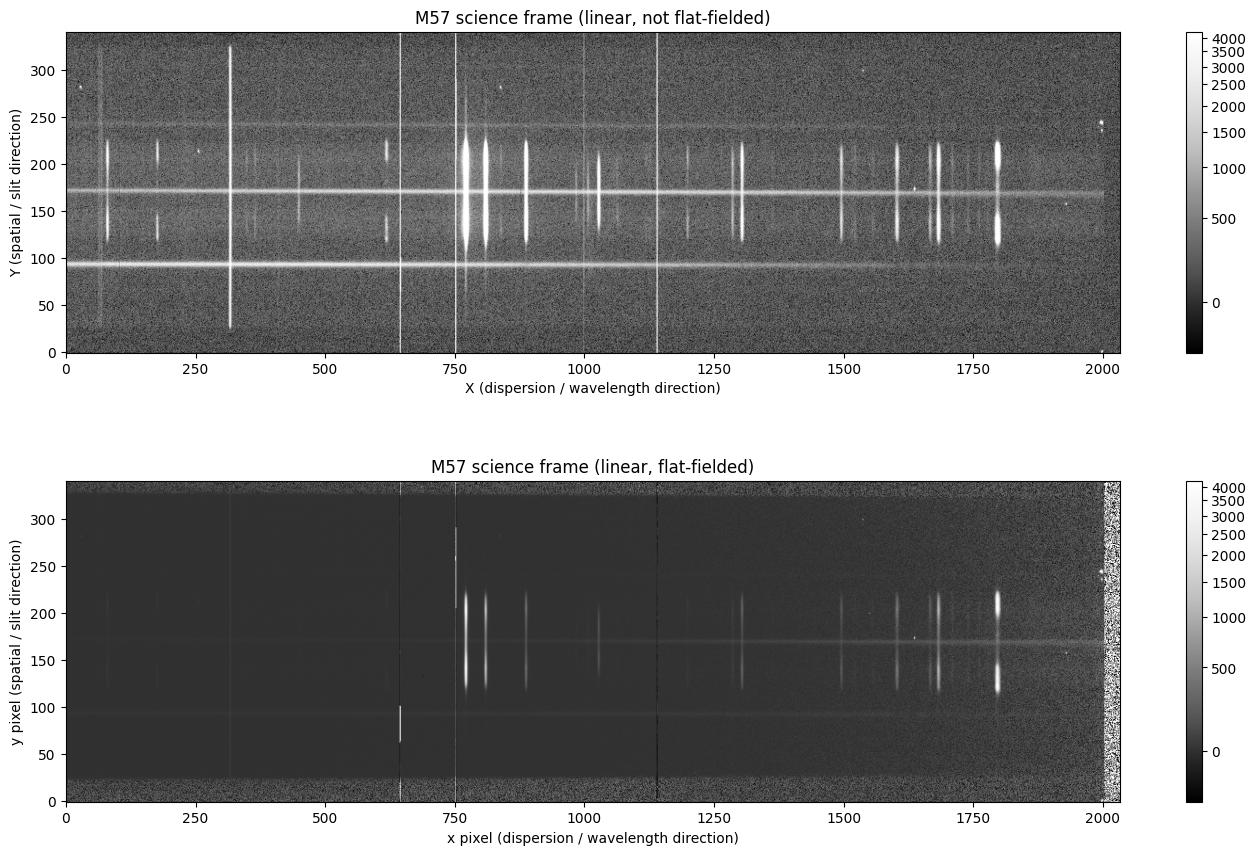

In [62]:
# Found a problem that if I didn't include the .astrype section, there would be overflow and every negative value would become positive again.
m57 = fits.open(FILES["m57"])[1].data.astype(np.float32)
zero = fits.open(FILES["zero"])[1].data.astype(np.float32)
flat = fits.open(FILES["flat"])[1].data.astype(np.float32)
arc = fits.open(FILES["arc"])[1].data.astype(np.float32)
print(np.max(m57))
# subtracting bias
m57_bs = m57 - zero
print(np.max(zero))
print(np.max(m57_bs))
arc_bs = arc - zero
flat = images['flat']
print(np.min(flat))

# subtracting bias first
flat_bs = flat - zero
flat_bs[~np.isfinite(flat_bs)] = np.nanmedian(flat_bs)

# normalize (avoid changing overall flux scale)
flat_norm = flat_bs / np.median(flat_bs)
print(np.median(flat_bs))
print(np.any(np.isnan(flat_norm)))

m57_flat = m57_bs / flat_norm


from astropy.visualization import simple_norm

fig, ax = plt.subplots(2, 1, figsize=(17, 10))

norm = simple_norm(m57, stretch='asinh', percent=98.5)
im = ax[0].imshow(m57, norm=norm, cmap='Grays_r', aspect='auto')
ax[0].set_title("M57 science frame (linear, not flat-fielded)")
ax[0].set_xlabel("X (dispersion / wavelength direction)")
ax[0].set_ylabel("Y (spatial / slit direction)")
norm = simple_norm(m57_flat, stretch='asinh', percent=98.5)
im = ax[1].imshow(m57_flat, norm=norm, cmap='Grays_r', aspect='auto')
ax[1].set_title("M57 science frame (linear, flat-fielded)")
ax[1].set_xlabel("x pixel (dispersion / wavelength direction)")
ax[1].set_ylabel("y pixel (spatial / slit direction)")

plt.colorbar(im, ax=ax[0], shrink=1)
plt.colorbar(im, ax=ax[1], shrink=1)
plt.subplots_adjust(hspace=0.4)
plt.show()

We can see the spectrum better in the non-flat-fielded image, which I annotate below:

<img src="annotated_spec.png" width="1400">

## P3. Rough wavelength calibration [10 pts]

In this section, you will derive a **rough wavelength solution** using the HeNeAr arc image.

A professional calibration would include a more careful treatment of distortions and nonlinearity. For this homework, a simple linear wavelength solution is enough:


$\lambda = \lambda_0 + \alpha x_{\rm pixel}$
 
 or 
 
$\lambda = \lambda_{\rm ref} + \alpha (x_{\rm pixel} - x_{\rm ref})$


where $x_{\rm pixel}$ is the detector pixel coordinate in the dispersion direction.

### Guidance
- The true solution is not perfectly linear, but this approximation is good enough for this homework.
- A useful clue is that the brightest emission feature in the Ring Nebula is usually **[O III] 5007 Å**, and in this dataset it appears near about **pixel 770**.
- The approximate dispersion is about **|$\alpha$| $\sim$ 1.24 Å/pixel**, but you must determine whether $\alpha$ is positive or negative and try to find a more exact value.  
- Use the arc lamp and a line list of strong **HeNeAr** lines to refine $\lambda_0$ and $\alpha$.

### Suggested approach
- Plot the arc spectrum using an approximate wavelength solution.
- Overplot known HeNeAr line wavelengths.
- Adjust $\lambda_0$ and $\alpha$ until the bright lines line up reasonably well.
- It is fine if some weaker or ambiguous lines remain unidentified.

### Required output
- A wavelength-calibrated 1D arc spectrum with many strong lines marked and labeled
- A short written explanation of how you determined $\lambda_0$ and $\alpha$
- Your final adopted values of $\lambda_0$ and $\alpha$

### Notes
You are **not** expected to derive a perfect professional calibration. A reasonable approximate solution is enough.

I give an example of the kind of labelling you need to do below (but without a perfect wavelength solution).
The dashed lines should match much better with slight tweaking of $\alpha$.

<img src="pics/poor_solution.jpg" width="1000">

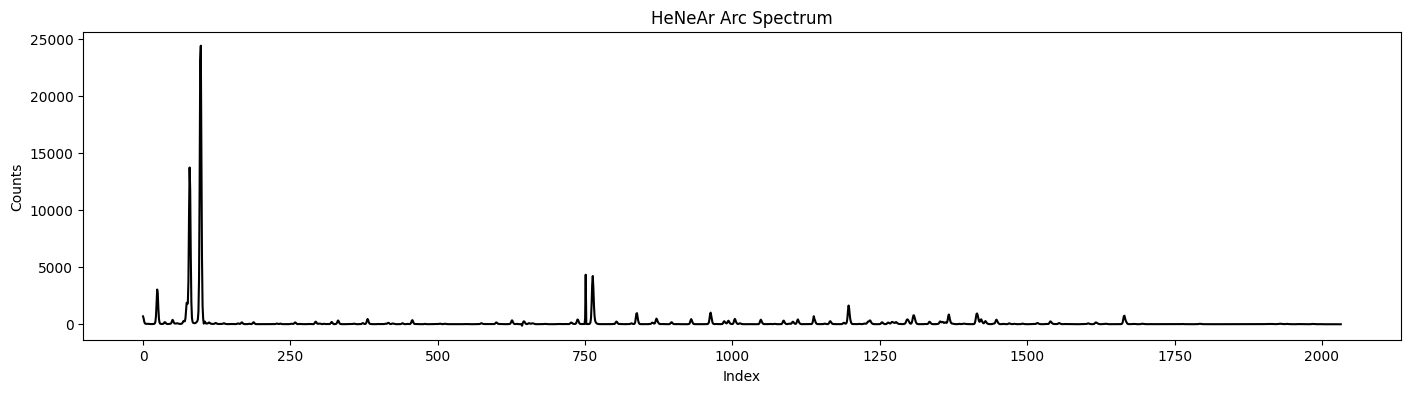

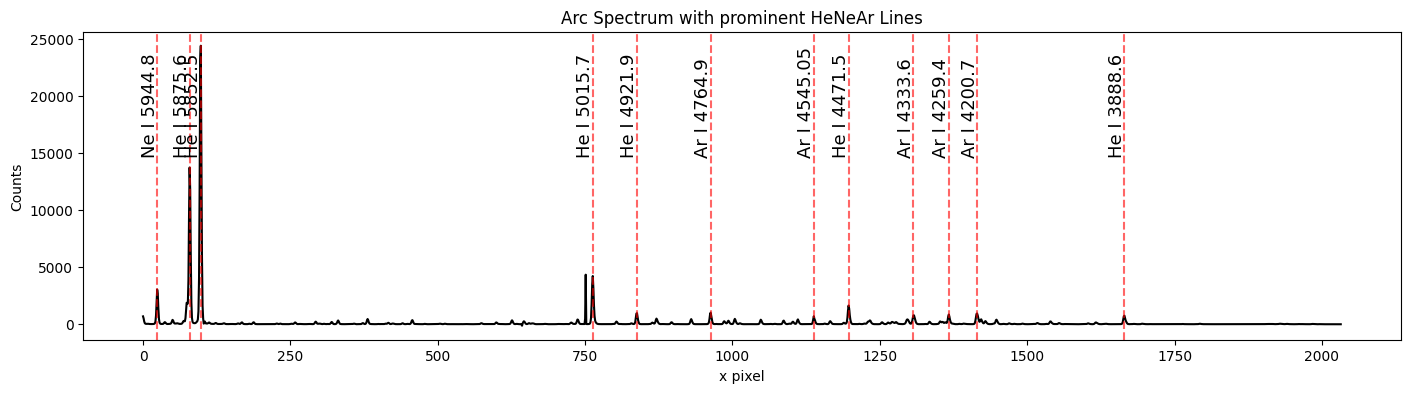

[-1.25440068e+00  5.97412625e+03]


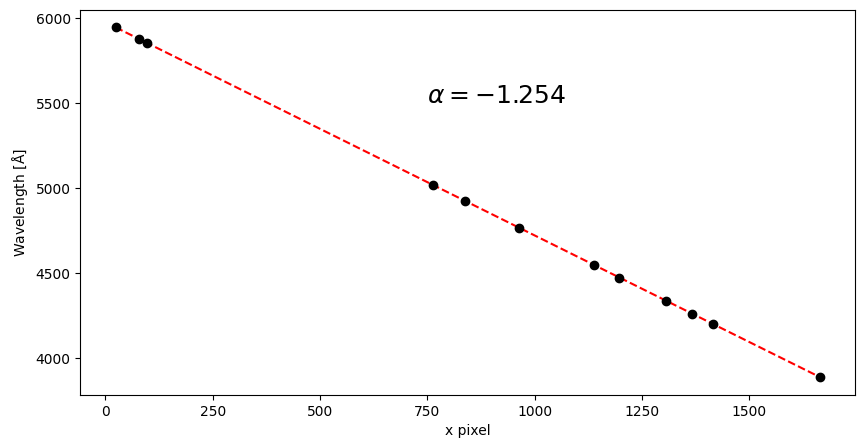

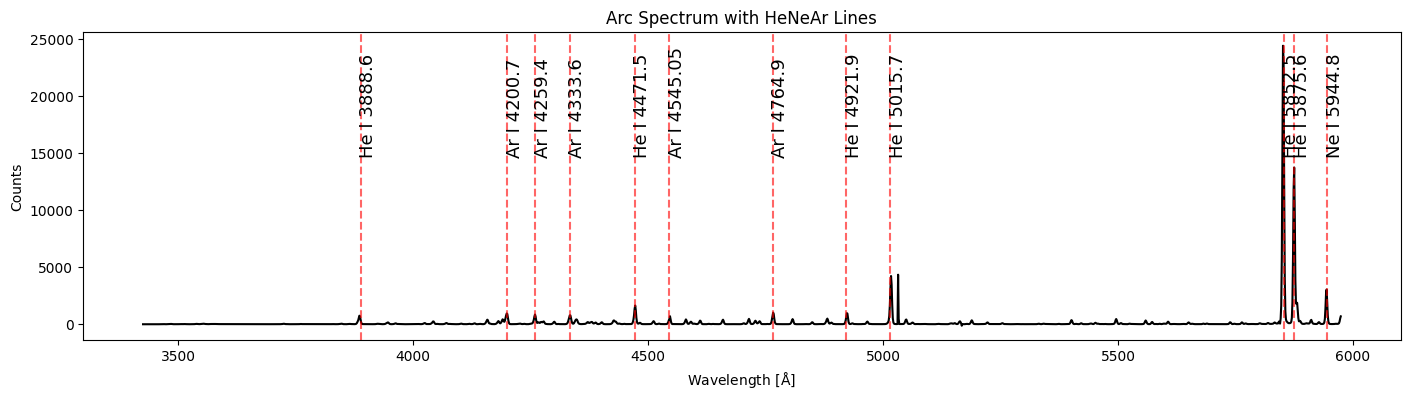

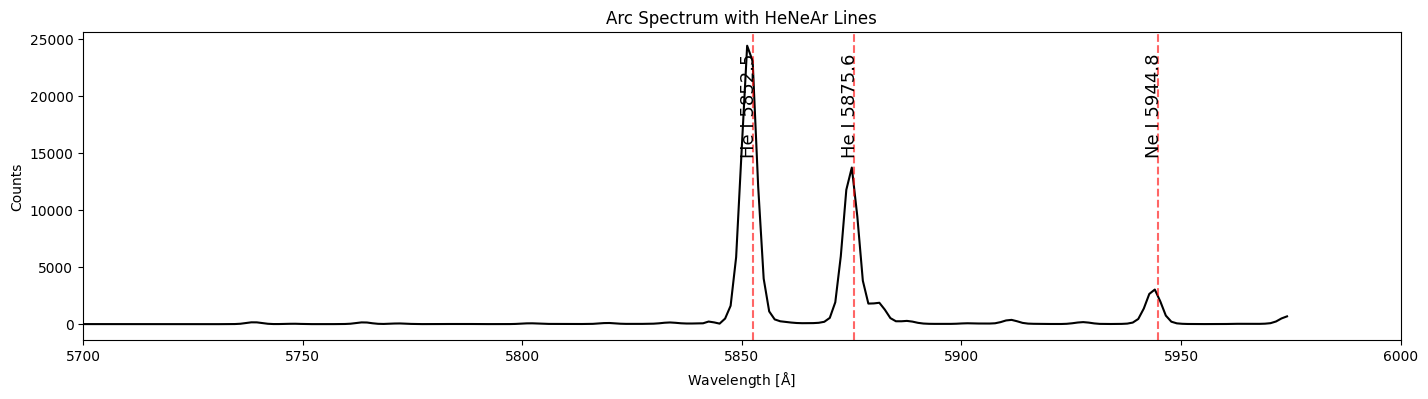

In [139]:
arc = arc_bs  # from previous reduction step

# collapse along slit direction (usually axis=0 or 1 — check orientation)
arc_1d = np.median(arc, axis=0)


plt.figure(figsize=(17,4))
plt.plot(arc_1d, color='black')

plt.xlabel("Index")
plt.ylabel("Counts")
plt.title("HeNeAr Arc Spectrum")
plt.show()


# Identify the most prominent lines

from scipy.signal import find_peaks
def get_lines_indices(valeurs: np.array,
                                      hauteur_minimum: int = None,
                                      distance_minimum: int = None):
    peaks, _ = find_peaks(valeurs, height=hauteur_minimum, distance=distance_minimum, prominence=500)
    return peaks


plt.figure(figsize=(17,4))
plt.plot(arc_1d, color='black')

detected_lines_ = list(get_lines_indices(arc_1d))
he_ne_ar_lines_ = [5944.8, 5875.6, 5852.5, np.nan, 5015.7, 4921.9, 4764.9, 4545.05, 4471.5, 4333.6, 4259.4, 4200.7, 3888.6]
he_ne_ar_lines_elem_ = ["Ne I", "He I","He I", np.nan, "He I", "He I", "Ar I", "Ar I", "He I", "Ar I", "Ar I", "Ar I", "He I"]

detected_lines = []
he_ne_ar_lines = []
he_ne_ar_lines_elem = []

for i in range(len(detected_lines_)):
    if not np.isnan(he_ne_ar_lines_[i]):
        detected_lines.append(detected_lines_[i])
        he_ne_ar_lines.append(he_ne_ar_lines_[i])
        he_ne_ar_lines_elem.append(he_ne_ar_lines_elem_[i])

for i,l in enumerate(detected_lines):
    plt.axvline(l, color='red', linestyle='--', alpha=0.6)
    plt.text(l-28, 15000, f"{he_ne_ar_lines_elem[i]} {he_ne_ar_lines[i]}", fontsize=13, color='black', rotation=90)
plt.xlabel("x pixel")
plt.ylabel("Counts")
plt.title("Arc Spectrum with prominent HeNeAr Lines")
plt.show()


# Find the wavelength solution
from scipy.optimize import curve_fit
params, _ = curve_fit(lambda x,a,b: a*x+b, detected_lines, he_ne_ar_lines)
print(params)
plt.plot(detected_lines, np.array(detected_lines)*params[0]+params[1], marker="None", ls="--", color="red")
plt.plot(detected_lines, he_ne_ar_lines, marker="o", ls="None", color="black")
plt.xlabel("x pixel")
plt.ylabel(r"Wavelength [$\mathrm{\AA}$]")
plt.text(750,5500,rf"$\alpha={params[0]:.3f}$",fontsize=18)
plt.show()

# Test wavelength solution by plotting lines
wave = np.arange(len(arc_1d))*params[0]+params[1]
plt.figure(figsize=(17,4))
plt.plot(wave, arc_1d, color='black')

for i,l in enumerate(he_ne_ar_lines):
    plt.axvline(l, color='red', linestyle='--', alpha=0.6)
    plt.text(l-3, 15000, f"{he_ne_ar_lines_elem[i]} {l}", fontsize=13, color='black', rotation=90)

plt.xlabel(r"Wavelength [$\mathrm{\AA}$]")
plt.ylabel("Counts")
plt.title("Arc Spectrum with HeNeAr Lines")
plt.show()
plt.figure(figsize=(17,4))
plt.plot(wave, arc_1d, color='black')

for i,l in enumerate(he_ne_ar_lines):
    if l > 5700 and l < 6000:
        plt.axvline(l, color='red', linestyle='--', alpha=0.6)
        plt.text(l-3, 15000, f"{he_ne_ar_lines_elem[i]} {l}", fontsize=13, color='black', rotation=90)

plt.xlabel(r"Wavelength [$\mathrm{\AA}$]")
plt.ylabel("Counts")
plt.title("Arc Spectrum with HeNeAr Lines")
plt.xlim(5700, 6000)
plt.show()

To perform a wavelength calibration with the HeNeAr arc, I decided to run a simple find_peaks routine to find the most prominent peaks that would be easy to identify, making a cut to choose only around 10 of them scattered throughout the whole range of the detector. I then used reference arcs from https://noirlab.edu/science/programs/ctio/retired-instruments/40-m-R-C-Spectrograph/Comparison-Atlases to identify which lines were identified, and proceeded to make a pixel-wavelength plot for the prominent lines. I made a simple linear curve_fit to the data
$$\lambda = \lambda_0 + \alpha x_\mathrm{px}$$
, which gave me $\alpha = -1.254$ and $\lambda_0=5974\mathrm{\AA}$. I finally plotted the resulting calibrated spectrum with the emission lines to verify the wavelength solution really lines up with the peaks observed.

## P4. Final spectra from different slit positions [15 pts]

Now apply your adopted wavelength solution to spectra extracted from several positions along the slit.

### Tasks
Choose slit positions corresponding approximately to:
- **sky**
- **central star**
- **inner nebula** (without the star, if possible)
- **outer nebula**

Extract and compare the spectra from these different regions.

### Required output
- Wavelength-calibrated spectra for multiple slit positions
- Plots that make it possible to compare both the strong lines and the weaker lines  
  (you may want multiple panels, different scalings, or both)

### Required features
- Label the major nebular lines
- Identify likely sky-glow / telluric features separately from nebular features
- Include short written comments describing how the spectra differ across the slit

### Things to discuss
- Which lines are strongest in the bright nebular ring?
- Does the central star show continuum?
- Which features appear to be sky residuals rather than true nebular emission?
- Do the relative line strengths help explain the visible colors in the Ring Nebula image?

Below are example plots showing the style I have in mind. The second set uses a stronger vertical stretch so weaker features are easier to see.

<img src="pics/ring_nebula_spectra.jpg" width="1000">
<img src="pics/ring_nebula_spectra_x25.jpg" width="1000">


## P5. Critique of the analysis [5 pts]

This homework uses many shortcuts. A real professional reduction would be more careful.

### Required text
Briefly discuss **at least three limitations** of your analysis and how a more careful reduction could improve the result.

Possible topics include:
- imperfect wavelength calibration, along slit direction
- nonlinearity of the wavelength solution
- sky subtraction
- bad pixels or cosmic rays
- flat-field limitations
- distortion along the slit
- order confusion
- lack of a true spectrophotometric calibration
- uncertainty in identifying weak lines

The goal here is not to apologize for the analysis, but to show that you understand what was simplified and why those simplifications matter.
